In [1]:
import pandas as pd # process and manipulate table data, implementing operations such as loading, aligning, merging, and transforming datasets efficiently
import numpy as np # numerical computing library for working with arrays and matrices, providing mathematical functions to operate on these data structures
import matplotlib.pyplot as plt # plotting library for creating static, animated, and interactive visualizations in Python
import os   # operating system interfaces for file and directory manipulation
import warnings # warning control to suppress or manage warning messages
import gsw  # Gibbs SeaWater (TEOS-10) oceanographic toolbox for seawater property calculations
print('gsw version:', gsw.__version__)

# Suppress pandas parsing warnings
warnings.filterwarnings('ignore', message="Could not infer format") 

gsw version: 3.6.21


# Water Surface Elevation Method

 This code calculates water surface elevation from the MeterCTD. Depth is derived some a simple power gain that is not available for public use. MeterCTD position is estimated from the surveyed OWLR to the NAVD88 Datum. The water level sensor on the OWLR is positioned at 846.8 cm above sealevel. CTD_hourly is calculated using two values. The value "706.14" is the estimated offset between the OWLR sensor and the MeterCTD in centimeters. The value "30.48" is the conversion factor from feet to centimeters.

 UPDATED!!! We moved the OWLR to the main pool so these measurements have changed. The OWLR is now at 860.24 cm above sea level and the offset between the OWLR and Hydros 21 (based on a set time) is 690.66 cm. I now download the Hydros21 in centimeters so do not need a conversion factor. The OWLR was moved on April 24th and the updated MaxSonar was replaced on May 4th at 12:30pm, therefore this time stamp begins at 1pm.


In [2]:
# -----------------------------
# Paths & time window
# -----------------------------
data_dir = "Data"

wse_CTD_path = os.path.join(data_dir, "wse_meterCTD_06162026.csv")
owlr_path    = os.path.join(data_dir, "waterLevel_OWLR_VP_06152026.csv")

start_time = pd.Timestamp("2026-05-14 00:00:00")
end_time   = pd.Timestamp("2026-06-14 00:00:00")


# -----------------------------
# Load CTD
# -----------------------------
def load_ctd(path):
    for enc in ["utf-8", "cp1252", "latin1"]:
        try:
            df = pd.read_csv(path, skiprows=5, encoding=enc)
            break
        except UnicodeDecodeError:
            continue

    df.columns = df.columns.str.strip()
    tcol, dcol = df.columns[:2]

    df[tcol] = pd.to_datetime(df[tcol], errors="coerce")
    df[dcol] = pd.to_numeric(df[dcol], errors="coerce")

    # Keep all valid timestamps (DO NOT filter minute/second)
    df = df[df[tcol].notna()]

    # time window filter
    df = df[(df[tcol] >= start_time) & (df[tcol] <= end_time)]

    # hourly binning (this is the correct step)
    df["timestamp_hour"] = df[tcol].dt.floor("h")

    df["WSE_CTD_cm"] = df[dcol] + 690.76

    # true hourly aggregation
    df = (
        df.groupby("timestamp_hour", as_index=False)["WSE_CTD_cm"]
        .mean()
    )

    return df


CTD_hourly = load_ctd(wse_CTD_path)


# -----------------------------
# Load OWLR (retain both raw and hourly data)
# -----------------------------
cols = [
    "device_id", "timestamp", "unused_1", "data_type",
    "epoch", "OWLR_value_cm", "rain_mm_raw", "col7", "col8"
]

owlr_raw = pd.read_csv(owlr_path, header=None, names=cols)

owlr_raw["timestamp"] = pd.to_datetime(owlr_raw["timestamp"], errors="coerce")
owlr_raw["OWLR_value_cm"] = pd.to_numeric(owlr_raw["OWLR_value_cm"], errors="coerce")
owlr_raw["rain_mm_raw"] = pd.to_numeric(owlr_raw["rain_mm_raw"], errors="coerce")

# Keep only rainfall rows; exclude variants like rainfall_0001
owlr_raw = owlr_raw[owlr_raw["data_type"].astype(str).str.strip().eq("rainfall")].copy()

owlr_raw["WSE_OWLR_cm"] = 860.24 - owlr_raw["OWLR_value_cm"]

owlr = owlr_raw[
    owlr_raw["timestamp"].notna()
    & (owlr_raw["timestamp"] >= start_time)
    & (owlr_raw["timestamp"] <= end_time)
] .copy()

owlr["timestamp_hour"] = owlr["timestamp"].dt.floor("h")

owlr = (
    owlr.groupby("timestamp_hour", as_index=False)["WSE_OWLR_cm"]
    .mean()
)


# -----------------------------
# Merge
# -----------------------------
comparison = (
    pd.merge(CTD_hourly, owlr, on="timestamp_hour", how="inner")
    .sort_values("timestamp_hour")
    .reset_index(drop=True)
)

print(f"Window: {start_time} to {end_time}")
print(f"CTD points: {len(CTD_hourly)}")
print(f"OWLR points: {len(owlr)}")
print(f"Matched points: {len(comparison)}")

print(f"Window: {start_time} to {end_time}")
print(f"OWLR (rainfall) hourly points: {len(owlr)}")
print(owlr.tail())



Window: 2026-05-14 00:00:00 to 2026-06-14 00:00:00
CTD points: 745
OWLR points: 728
Matched points: 728
Window: 2026-05-14 00:00:00 to 2026-06-14 00:00:00
OWLR (rainfall) hourly points: 728
         timestamp_hour  WSE_OWLR_cm
723 2026-06-13 20:00:00    716.87055
724 2026-06-13 21:00:00    714.96501
725 2026-06-13 22:00:00    715.37333
726 2026-06-13 23:00:00    714.98583
727 2026-06-14 00:00:00    714.94277


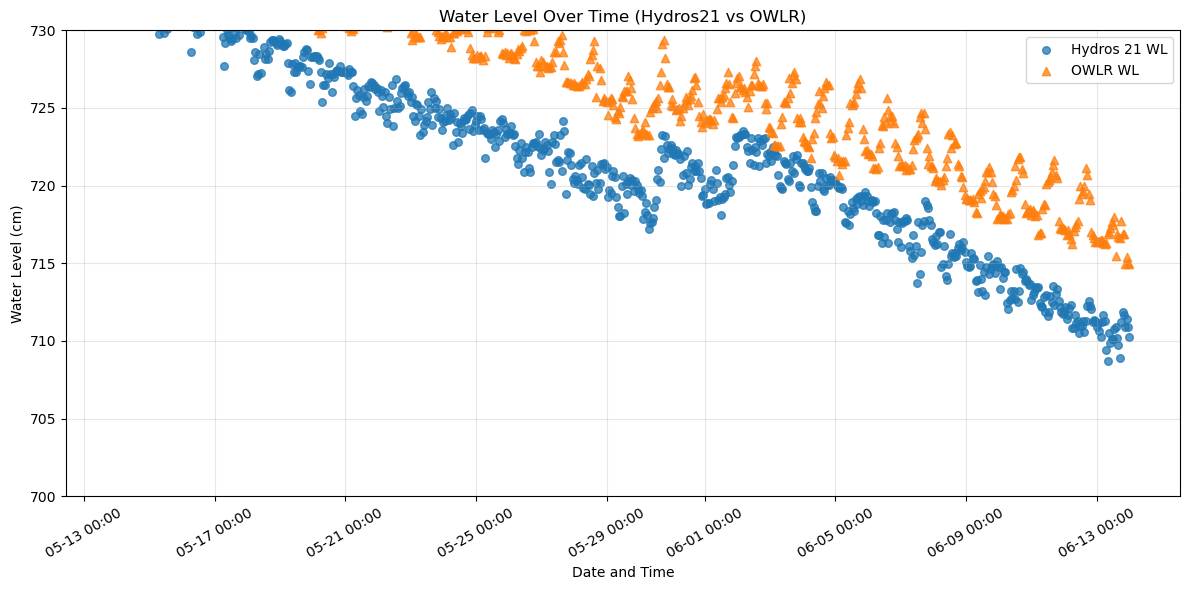

Hydros 21 points shown: 745
OWLR points shown: 728
Overlapping timestamps: 728


In [3]:
# -----------------------------
# Plot all available hourly points (no inner-join filtering)
# -----------------------------
if 'CTD_hourly' not in globals() or 'owlr' not in globals():
    raise ValueError('Run the data-loading cell first.')

import matplotlib.dates as mdates

ctd_plot = CTD_hourly.sort_values('timestamp_hour').copy()
owlr_plot = owlr.sort_values('timestamp_hour').copy()

plt.figure(figsize=(12, 6))

plt.scatter(
    ctd_plot['timestamp_hour'],
    ctd_plot['WSE_CTD_cm'],
    s=30, marker='o', alpha=0.75, label='Hydros 21 WL'
 )

plt.scatter(
    owlr_plot['timestamp_hour'],
    owlr_plot['WSE_OWLR_cm'],
    s=36, marker='^', alpha=0.75, label='OWLR WL'
 )

plt.title('Water Level Over Time (Hydros21 vs OWLR)')
plt.xlabel('Date and Time')
plt.ylabel('Water Level (cm)')
plt.ylim(700, 730)

# Format x-axis ticks as mm-dd hh:mm
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=6, maxticks=14))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.xticks(rotation=30)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

matched_only = pd.merge(
    ctd_plot[['timestamp_hour']],
    owlr_plot[['timestamp_hour']],
    on='timestamp_hour',
    how='inner'
 )

print(f'Hydros 21 points shown: {len(ctd_plot)}')
print(f'OWLR points shown: {len(owlr_plot)}')
print(f'Overlapping timestamps: {len(matched_only)}')

# Updated Hydros 21 depth based on TEOS-10 algorithms


In [4]:
import matplotlib.dates as mdates

# UNCW CMS Pond, Wilmington NC location for TEOS-10 SA calculation
SITE_LAT = 34.14308396
SITE_LON = -77.87035498

# Load full CTD data with temperature and conductivity columns
# Columns: Date & Time | Fluid Depth - cm | Temp - C | EC - dS/m
try:
    CTD_teos_raw = pd.read_csv(wse_CTD_path, skiprows=5, encoding='utf-8')
except UnicodeDecodeError:
    try:
        CTD_teos_raw = pd.read_csv(wse_CTD_path, skiprows=5, encoding='cp1252')
    except UnicodeDecodeError:
        CTD_teos_raw = pd.read_csv(wse_CTD_path, skiprows=5, encoding='latin1')
CTD_teos_raw.columns = [str(c).strip() for c in CTD_teos_raw.columns]

teos_time_col = CTD_teos_raw.columns[0]
teos_depth_col = CTD_teos_raw.columns[1]
teos_temp_col = CTD_teos_raw.columns[2]
teos_ec_col = CTD_teos_raw.columns[3]

CTD_teos_raw[teos_time_col] = pd.to_datetime(CTD_teos_raw[teos_time_col], errors='coerce')
CTD_teos_raw[teos_depth_col] = pd.to_numeric(CTD_teos_raw[teos_depth_col], errors='coerce')
CTD_teos_raw[teos_temp_col] = pd.to_numeric(CTD_teos_raw[teos_temp_col], errors='coerce')
CTD_teos_raw[teos_ec_col] = pd.to_numeric(CTD_teos_raw[teos_ec_col], errors='coerce')

# Keep only exact hourly marks within the comparison window
CTD_teos = CTD_teos_raw[
    CTD_teos_raw[teos_time_col].notna()
    & (CTD_teos_raw[teos_time_col].dt.minute == 0)
    & (CTD_teos_raw[teos_time_col].dt.second == 0)
    & (CTD_teos_raw[teos_time_col] >= start_time)
    & (CTD_teos_raw[teos_time_col] <= end_time)
].copy()  # Independent copy for safe downstream column edits

# Step 1: set units
CTD_teos['temp_C'] = CTD_teos[teos_temp_col]
CTD_teos['cond_mScm'] = CTD_teos[teos_ec_col]  # dS/m == mS/cm numerically

# Step 2: back-calculate pressure assuming rho = 1.000 g/cm^3
#  Calc I used is P (dbar) = rho * g * h / 10000  where rho=1000 kg/m^3, g=9.81 m/s^2, h in meters
CTD_teos['depth_m'] = CTD_teos[teos_depth_col] / 100.0
CTD_teos['P_dbar'] = 1000 * 9.81 * CTD_teos['depth_m'] / 10000

# Step 3: Practical Salinity from conductivity, temperature, pressure
CTD_teos['SP'] = gsw.SP_from_C(CTD_teos['cond_mScm'], CTD_teos['temp_C'], CTD_teos['P_dbar'])

# Step 4: Absolute Salinity
CTD_teos['SA'] = gsw.SA_from_SP(CTD_teos['SP'], CTD_teos['P_dbar'], SITE_LON, SITE_LAT)

# Step 5: Conservative Temperature
CTD_teos['CT'] = gsw.CT_from_t(CTD_teos['SA'], CTD_teos['temp_C'], CTD_teos['P_dbar'])

# Step 6: In-situ density (kg/m^3)
CTD_teos['rho'] = gsw.rho(CTD_teos['SA'], CTD_teos['CT'], CTD_teos['P_dbar'])

# Step 7: corrected depth using new time-varying density
CTD_teos['depth_corrected_cm'] = (CTD_teos['P_dbar'] * 10000) / (CTD_teos['rho'] * 9.81) * 100

# new CTD_teos wse within timeframe
CTD_teos['WSE_CTD_teos_cm'] = CTD_teos['depth_corrected_cm'] + 706.14
CTD_teos['timestamp_hour'] = CTD_teos[teos_time_col].dt.floor('h')
CTD_teos_hourly = CTD_teos[['timestamp_hour', 'WSE_CTD_teos_cm', 'rho', 'SP']]

# WSE_CTD - CTD_teos
ctd_delta = pd.merge(
    CTD_hourly[['timestamp_hour', 'WSE_CTD_cm']],
    CTD_teos_hourly[['timestamp_hour', 'WSE_CTD_teos_cm']],
    on='timestamp_hour',
    how='inner'
)
ctd_delta['WSE_CTD_minus_TEOS_cm'] = ctd_delta['WSE_CTD_cm'] - ctd_delta['WSE_CTD_teos_cm']

# OWLR calibrated hourly rainfall (new format: rain_mm_raw already in column 6)
owlr_rain_hourly = owlr_raw[
    owlr_raw['timestamp'].notna()
    & (owlr_raw['timestamp'] >= start_time)
    & (owlr_raw['timestamp'] <= end_time)
] .copy()
owlr_rain_hourly['timestamp_hour'] = owlr_rain_hourly['timestamp'].dt.floor('h')
owlr_rain_hourly = owlr_rain_hourly.groupby('timestamp_hour', as_index=False)['rain_mm_raw'].sum()

# From rainfallAnalysis.ipynb direct-comparison calibration: TR-525l = m * OWLR_raw + b
RAIN_CAL_M = 0.5404
RAIN_CAL_B = 0.0452
owlr_rain_hourly['rain_mm_owlr_cal'] = (RAIN_CAL_M * owlr_rain_hourly['rain_mm_raw'] + RAIN_CAL_B).clip(lower=0)

# Merge with OWLR
comparison_teos = pd.merge(CTD_teos_hourly, owlr, on='timestamp_hour', how='inner').dropna()
comparison_teos = comparison_teos.sort_values('timestamp_hour').reset_index(drop=True)

print(f'Matched TEOS-10 comparison points: {len(comparison_teos)}')
print(f'Mean density (kg/m^3):     {comparison_teos["rho"].mean():.4f}')
print(f'Mean Practical Salinity:  {comparison_teos["SP"].mean():.4f}')
print(f"Mean (WSE_CTD - CTD_teos) cm: {ctd_delta['WSE_CTD_minus_TEOS_cm'].mean():.4f}")




Matched TEOS-10 comparison points: 726
Mean density (kg/m^3):     996.2121
Mean Practical Salinity:  0.0776
Mean (WSE_CTD - CTD_teos) cm: -15.5315


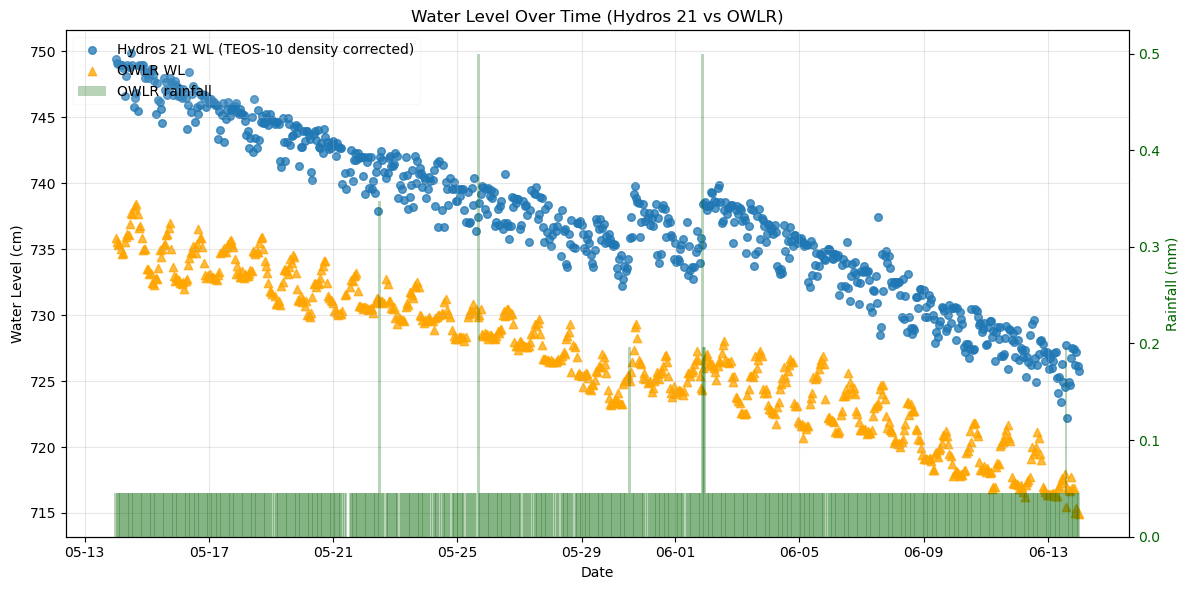

,timestamp_hour,WSE_CTD_cm,WSE_CTD_teos_cm,WSE_CTD_minus_TEOS_cm
0,2026-05-14 00:00:00,733.785,749.463755,-15.678755
1,2026-05-14 01:00:00,733.610,749.160686,-15.550686
2,2026-05-14 02:00:00,733.535,749.058216,-15.523216
3,2026-05-14 03:00:00,733.610,749.056044,-15.446044
4,2026-05-14 04:00:00,733.435,748.953623,-15.518623


In [5]:
# Plot
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.scatter(
    comparison_teos['timestamp_hour'],
    comparison_teos['WSE_CTD_teos_cm'],
    s=30,
    marker='o',
    alpha=0.75,
    label='Hydros 21 WL (TEOS-10 density corrected)'
)
ax1.scatter(
    comparison_teos['timestamp_hour'],
    comparison_teos['WSE_OWLR_cm'],
    s=36,
    marker='^',
    color='orange',
    alpha=0.75,
    label='OWLR WL'
)

# Use only OWLR rainfall values that match comparison timestamps
rain_plot = pd.merge(
    comparison_teos[['timestamp_hour']],
    owlr_rain_hourly[['timestamp_hour', 'rain_mm_owlr_cal']],
    on='timestamp_hour',
    how='left'
).fillna({'rain_mm_owlr_cal': 0})

ax2.bar(
    rain_plot['timestamp_hour'],
    rain_plot['rain_mm_owlr_cal'],
    width=0.09,
    color='darkgreen',
    alpha=0.28,
    label='OWLR rainfall'
)

ax1.set_title('Water Level Over Time (Hydros 21 vs OWLR)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Water Level (cm)')
ax2.set_ylabel('Rainfall (mm)', color='darkgreen')
ax2.tick_params(axis='y', labelcolor='darkgreen')
ax1.grid(True, alpha=0.3)

# Clean x-axis labels: show month-day only
date_locator = mdates.AutoDateLocator(minticks=8, maxticks=14)
date_formatter = mdates.DateFormatter('%m-%d')
ax1.xaxis.set_major_locator(date_locator)
ax1.xaxis.set_major_formatter(date_formatter)
plt.xticks(rotation=30)

# Combined legend
handles_1, labels_1 = ax1.get_legend_handles_labels()
handles_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(handles_1 + handles_2, labels_1 + labels_2, loc='upper left', framealpha=0.1)

plt.tight_layout()
plt.show()

ctd_delta[['timestamp_hour', 'WSE_CTD_cm', 'WSE_CTD_teos_cm', 'WSE_CTD_minus_TEOS_cm']].head()

# CTD (noTEOS) vs OWLR scatter plot with best-fit line and R^2


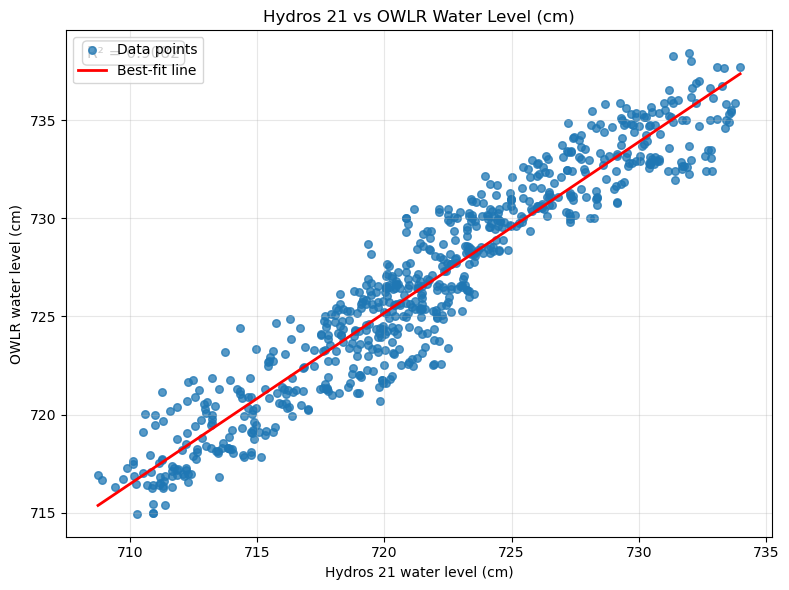

Best-fit line: y = 0.8716x + 97.5991
R² = 0.9082


In [6]:
# -----------------------------
# Check data availability
# -----------------------------
if "comparison" not in globals() or comparison.empty:
    raise ValueError("Run Cell 3 first so comparison data is available.")

# -----------------------------
# Extract and clean data
# -----------------------------
x = pd.to_numeric(comparison["WSE_CTD_cm"], errors="coerce").to_numpy(dtype=float)
y = pd.to_numeric(comparison["WSE_OWLR_cm"], errors="coerce").to_numpy(dtype=float)

valid_mask = np.isfinite(x) & np.isfinite(y)
x = x[valid_mask]
y = y[valid_mask]

if len(x) < 2:
    raise ValueError("Not enough valid paired points for regression after cleaning data.")

if np.allclose(np.std(x), 0):
    raise ValueError("X values are constant; cannot compute regression line.")

# -----------------------------
# Linear regression
# -----------------------------
m, b = np.polyfit(x, y, 1)
y_pred = m * x + b

# R² calculation
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

# -----------------------------
# Plot results
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(x, y, s=30, alpha=0.75, label="Data points")

x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, m * x_line + b, color="red", linewidth=2, label="Best-fit line")

ax.set_title("Hydros 21 vs OWLR Water Level (cm)")
ax.set_xlabel("Hydros 21 water level (cm)")
ax.set_ylabel("OWLR water level (cm)")
ax.grid(True, alpha=0.3)
ax.legend()

# R² annotation
ax.text(
    0.03, 0.97,
    f"R² = {r2:.4f}" if np.isfinite(r2) else "R² = n/a",
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=11,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.show()

# -----------------------------
# Output summary
# -----------------------------
print(f"Best-fit line: y = {m:.4f}x + {b:.4f}")
print(f"R² = {r2:.4f}" if np.isfinite(r2) else "R² = n/a")

# CTD TEOS-10 corrected vs OWLR scatter with best-fit line and R^2

Mean (WSE_CTD - CTD_teos) cm: -0.0672

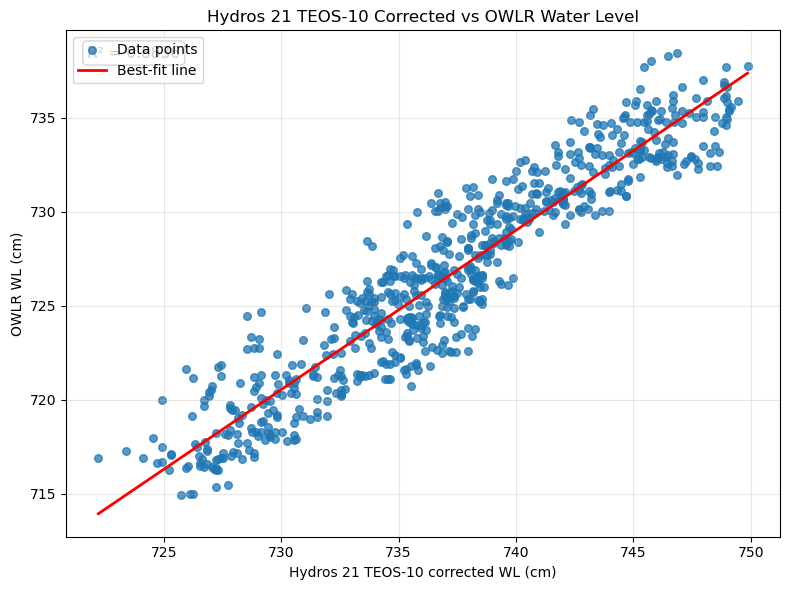

Correlated Hydros-OWLR paired values: 726
Best-fit line: y = 0.8478x + 101.6580
R² = 0.8836


In [7]:
if 'comparison_teos' not in globals() or comparison_teos.empty:
    raise ValueError('Run Cell 4 first so TEOS comparison data is available.')

x = pd.to_numeric(comparison_teos['WSE_CTD_teos_cm'], errors='coerce').to_numpy(dtype=float)
y = pd.to_numeric(comparison_teos['WSE_OWLR_cm'], errors='coerce').to_numpy(dtype=float)

# Keep only finite paired points to avoid linear algebra failures in polyfit
valid = np.isfinite(x) & np.isfinite(y)
x = x[valid]
y = y[valid]

if len(x) < 2:
    raise ValueError('Not enough valid paired TEOS points for regression after removing non-finite values.')

if np.allclose(np.std(x), 0):
    raise ValueError('Hydros 21 TEOS values are constant; cannot compute a regression line.')

# best-fit line
m, b = np.polyfit(x, y, 1)
y_fit = m * x + b

# R²
ss_res = np.sum((y - y_fit) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else np.nan

plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=30, alpha=0.75, marker='o', label='Data points')

x_line = np.linspace(np.min(x), np.max(x), 200)
y_line = m * x_line + b
plt.plot(x_line, y_line, color='red', linewidth=2, label='Best-fit line')

plt.title('Hydros 21 TEOS-10 Corrected vs OWLR Water Level')
plt.xlabel('Hydros 21 TEOS-10 corrected WL (cm)')
plt.ylabel('OWLR WL (cm)')
plt.grid(True, alpha=0.3)
plt.legend()

ax = plt.gca()
ax.text(
    0.03,
    0.97,
    f'R² = {r2:.4f}' if np.isfinite(r2) else 'R² = n/a',
    transform=ax.transAxes,
    fontsize=11,
    va='top',
    ha='left',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.tight_layout()
plt.show()

print(f'Correlated Hydros-OWLR paired values: {len(x)}')
print(f'Best-fit line: y = {m:.4f}x + {b:.4f}')
print(f'R² = {r2:.4f}' if np.isfinite(r2) else 'R² = n/a')

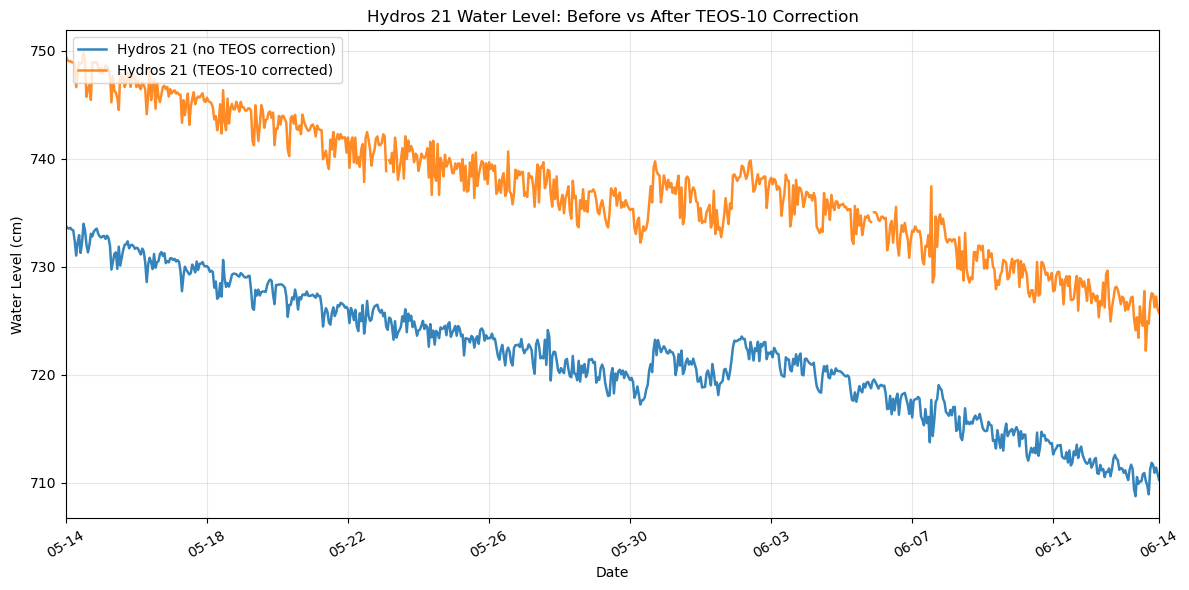

Window: 2026-05-14 00:00:00 to 2026-06-14 00:00:00
Plotted Hydros 21 hourly points: 745
Average difference (no TEOS correction - TEOS correction), cm: -15.5315


In [18]:
if "CTD_hourly" not in globals() or "CTD_teos_hourly" not in globals():
    raise ValueError("Run the CTD and TEOS processing cells first.")

hydros_plot = CTD_hourly[["timestamp_hour", "WSE_CTD_cm"]].merge(
    CTD_teos_hourly[["timestamp_hour", "WSE_CTD_teos_cm"]],
    on="timestamp_hour",
    how="inner",
)
hydros_plot["timestamp_hour"] = pd.to_datetime(hydros_plot["timestamp_hour"], errors="coerce")
hydros_plot = hydros_plot[
    hydros_plot["timestamp_hour"].between(start_time, end_time)
] .dropna(subset=["timestamp_hour"]).sort_values("timestamp_hour").copy()

if hydros_plot.empty:
    raise ValueError("No overlapping Hydros 21 data found in the selected time window.")

avg_diff_cm = (hydros_plot["WSE_CTD_cm"] - hydros_plot["WSE_CTD_teos_cm"]).mean()

fig, ax = plt.subplots(figsize=(12, 6))
x = hydros_plot["timestamp_hour"].to_numpy()
ax.plot(x, hydros_plot["WSE_CTD_cm"], linewidth=1.8, alpha=0.9, label="Hydros 21 (no TEOS correction)")
ax.plot(x, hydros_plot["WSE_CTD_teos_cm"], linewidth=1.8, alpha=0.9, label="Hydros 21 (TEOS-10 corrected)")

ax.set(
    title="Hydros 21 Water Level: Before vs After TEOS-10 Correction",
    xlabel="Date",
    ylabel="Water Level (cm)",
)
ax.set_xlim(start_time, end_time)
ax.grid(True, alpha=0.3)

tick_dates = pd.date_range(start=start_time, end=end_time, freq="4D")
tick_dates = tick_dates.union(pd.DatetimeIndex([start_time, end_time])).sort_values()
ax.set_xticks(tick_dates)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
plt.xticks(rotation=30)

plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

print(f"Window: {start_time} to {end_time}")
print(f"Plotted Hydros 21 hourly points: {len(hydros_plot)}")
print(f"Average difference (no TEOS correction - TEOS correction), cm: {avg_diff_cm:.4f}")